# Configuring the BREADS pipeline analysis

For performance reasons, we configure these various environement variables to prevent numpy from internally parallelizing certain function calls internally which are used during parallelized steps in the analysis pipeline. This cell must be run *before* numpy is imported for them to be recognized.

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"        # export OMP_NUM_THREADS=1
os.environ["OPENBLAS_NUM_THREADS"] = "1"   # export OPENBLAS_NUM_THREADS=1 
os.environ["MKL_NUM_THREADS"] = "1"        # export MKL_NUM_THREADS=1
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" # export VECLIB_MAXIMUM_THREADS=1
os.environ["NUMEXPR_NUM_THREADS"] = "1"    # export NUMEXPR_NUM_THREADS=1

**This cell must be modified!** Specify the directory where you previously stored the data products

In [2]:
base_path = '/astro/epsig/tutorial/'

Creating even more subdirectories for organizing data products.

In [3]:
data_path = base_path+'data/'
raw_path = data_path+'raw/'
output_path = base_path+'outputs/'
PSF_path = base_path+'PSFs/' 

create_paths = [base_path,data_path,raw_path,output_path,PSF_path]
for path in create_paths:
    if not os.path.exists(path):
        os.mkdir(path)

**This cell must be modified!** The JWST pipeline requires configuring an environment variable ```CRDS_PATH``` for storing various calibration reference data, while the BREADS pipeline requires installation of STPSF/WEBBPSF for computing synthethic point spread functions used during the modelling.

In [4]:
crds_dir = '/astro/epsig/crds_cache'
os.environ['CRDS_PATH'] = crds_dir
os.environ['CRDS_SERVER_URL'] = 'https://jwst-crds.stsci.edu'
os.environ['WEBBPSF_PATH'] = '/home/amadurowicz/webbpsf-data/'

Time to import a bunch of stuff.

In [5]:
import time
import jwst
print('JWST pipeline version',jwst.__version__) # Print out what pipeline version we're using

from multiprocess import Pool
import numpy as np
import datetime
from copy import copy
from glob import glob

from astropy.io import fits
from astropy import constants as const
from astropy.table import Table
import astropy.units as u

from  scipy.interpolate import interp1d
from scipy.interpolate import LinearNDInterpolator

import matplotlib.pyplot as plt
import matplotlib

from breads.jwst_tools.reduction_utils import find_files_to_process
from breads.jwst_tools.reduction_utils import run_stage1,run_stage2
from breads.jwst_tools.reduction_utils import run_coordinate_recenter
from breads.jwst_tools.reduction_utils import run_noise_clean
from breads.jwst_tools.reduction_utils import compute_normalized_stellar_spectrum
from breads.jwst_tools.reduction_utils import compute_starlight_subtraction
from breads.jwst_tools.reduction_utils import get_combined_regwvs
from breads.jwst_tools.reduction_utils import get_2D_point_cloud_interpolator
from breads.jwst_tools.reduction_utils import save_combined_regwvs

from breads.instruments.jwstnirspec_cal import build_cube
from breads.utils import rotate_coordinates

numthreads = os.cpu_count()

JWST pipeline version 1.20.2


The follwing saves the pre-configured non-uniform nodes defined by Ruffio et al. 2025.

In [6]:
wv_nodes_dict = {'nrs1': np.array([2.859, 2.879, 2.899, 2.919, 2.939, 2.959, 2.979, 2.999, 3.019,
                                   3.039, 3.059, 3.079, 3.099, 3.119, 3.139, 3.159, 3.189, 3.219,
                                   3.249, 3.279, 3.309, 3.339, 3.369, 3.399, 3.429, 3.459, 3.499,
                                   3.539, 3.579, 3.619, 3.659, 3.699, 3.739, 3.779, 3.839, 3.899,
                                   3.959, 4.019, 4.079, 4.139]),
                 'nrs2': np.array([4.081, 4.141, 4.201, 4.261, 4.321, 4.361, 4.401, 4.441, 4.481,
                                   4.521, 4.561, 4.601, 4.641, 4.671, 4.701, 4.731, 4.761, 4.791,
                                   4.821, 4.851, 4.881, 4.911, 4.941, 4.971, 4.991, 5.011, 5.031,
                                   5.051, 5.071, 5.091, 5.111, 5.131, 5.151, 5.171, 5.191, 5.211,
                                   5.231, 5.251, 5.271, 5.291])}

np.save(base_path+'nonuniform_nodes.npy',wv_nodes_dict)
wv_nodes_dict

{'nrs1': array([2.859, 2.879, 2.899, 2.919, 2.939, 2.959, 2.979, 2.999, 3.019,
        3.039, 3.059, 3.079, 3.099, 3.119, 3.139, 3.159, 3.189, 3.219,
        3.249, 3.279, 3.309, 3.339, 3.369, 3.399, 3.429, 3.459, 3.499,
        3.539, 3.579, 3.619, 3.659, 3.699, 3.739, 3.779, 3.839, 3.899,
        3.959, 4.019, 4.079, 4.139]),
 'nrs2': array([4.081, 4.141, 4.201, 4.261, 4.321, 4.361, 4.401, 4.441, 4.481,
        4.521, 4.561, 4.601, 4.641, 4.671, 4.701, 4.731, 4.761, 4.791,
        4.821, 4.851, 4.881, 4.911, 4.941, 4.971, 4.991, 5.011, 5.031,
        5.051, 5.071, 5.091, 5.111, 5.131, 5.151, 5.171, 5.191, 5.211,
        5.231, 5.251, 5.271, 5.291])}

This cell configures various aspects in the analysis.

- targetname: SIMBAD resolve-able name for the host to obtain sky coordinates
- grating: 'G395H' is supported for now. Other gratings are WIP.
- mask_charge_transfer_radius: either 'None' or float (in arcsec) half-width of rectangular region to mask around stellar charge bleed. 0.1 is a reasonable value
- model_charge_transfer: boolean. (Experimental) subtraction of unilluminated pixels in rate files using Lorentzian-based model. 

In [7]:
targetname = 'HD 19467'
grating = 'G395H'
mask_charge_transfer_radius = None
model_charge_transfer = False

### Running the pipeline

Below is a behemoth of a function which combines multiple steps in the analysis chain into a single call. The intention is to use this function to conveniently to loop over both detectors ```nrs1``` and ```nrs2``` and various sequence numbers while running the same code. It could also be used to iterate over other parameters such as ```targetname``` if you have multiple datasets on different objects. For pedagogical purposes it would be preferable to split it apart for more localized explanations, however, what follows will be (1) the broad purposes of this function (2) the long function itself and (3) calling the function with a simple loop over both detectors.

Step 0: Preparations
- The detector argument selects the node specification from the dictionary loaded ealier
- The filename_filter and detector are used to construct the glob string to find the observation files
- Paths to various ```/data/``` subdirectories are created for intermediate data products, including unique idenfiers for charge transfer modelling or joint sequence modelling to avoid mixtures.

Step 1: JWST pipeline
- Stages 1 and 2 of the JWST pipeline are run on the observations found with the glob string.
- The exact parameters passed to the pipeline are hard coded inside the ```run_stage1``` and ```run_stage2``` functions

Step 2: Sky coordinate calibration
- This is a two-step iterative process to correct the JWST pipeline provided coordinates.
- Inside ```run_coordiante_recenter```, ```fitpsf``` is used to find the best-fit coordinates for the star as a function of wavelength by fitting a PSF model to the stage 2 calibrated data.
- The first iteration is initialized at (0,0), while the second iteration is initialized at the best fit centroid of the previous step.

Step 3: 1/f noise clean (and) charge transfer modelling
- The coordinate corrections are applied to the post-stage 1 rate files.
- A simple linear 1/f noise correction is applied to the rate data to remove striping artifacts
- If ```model_charge_transfer=True```, then a more complicated lorentzian-based model of the charge bleeding profile is also subtracted from the rate files. This step is experiemental and the Lorentzian model is still in development. For the tutorial we have disabled it for this analysis since HD 19467 B is widely separated it is non-issue. But for targets very close in ( < 0.3" separation) this could be very helpful.

Step 4: JWST stage 2 pipeline again (post charge bleed model)
- Stage 2 of the JWST pipeline is run to produce cal files which have 1/f noise and charge bleeding corrections applied

Step 5: Computing the (high pass filtered) stellar spectrum
- ```compute_normalized_stellar_spectrum``` is called on the cal files to obtain the high-frequency components of the starlight model.
- The argument ```ra_dec_point_sources``` can be used to mask out the region corresponding to the planet signal or other interlopers in the FOV. This argument expects an ```(ra,dec)``` tuple in units of milliarcseconds. However, this argument is skipped here.

Step 6: Subtracting starlight model (spline and high frequency components)
- ```compute_starlight_subtraction``` is called on cal files using the starlight spectrum computed previously. This combines the spline continuum model with the high frequency stellar spectrum to produce continuum-subtracted detector data.

Step 7: Creating the point-cloud interpolator (for unsubtracted PSF visualization)
- ```get_combined_regwvs``` is used with the arugment ```use_starsub=False``` to interpolate the non-star-subtracted detector data onto a regular wavelength grid and to stack the sequence of data objects into single instance
- if ```JOINT=False``` and we are only modelling a single sequence we call ```regwvs_combdataobj.set_coords2ifu()``` to transform from sky to IFU coordinates, otherwise the ```JOINT``` modelling remains in sky coordinates to stack observations at different roll angles / dither positions properly.
- ```get_2D_point_cloud_interpolator``` is called to transform the stacked detector data into an interpolation function internally relying on ```matplotlib.tri.LinearTriInterpolator``` to make a linear interpolation triangular mesh of the non-uniform spaced point cloud data
- ```save_combined_regwvs``` is called to save this object into the ```/PSFs/``` subfolder for later access, while the ```analysis_chain()``` function returns the ```pointcloud_interp``` object so we can directly call it later in this script.

Step 8: Preparing for ```build_cube```
- ```get_combined_regwvs``` is called with ```use_starsub=True```. This will do the same regular wavelength interpolation and sequence stacking from Step 7 but this time on the detector data with the starlight subtracted. This forms the primary input for the final step for building the spectral cube.
- Similarly, if ```JOINT=False``` and we are only modelling a single sequence we call ```regwvs_starsub_combdataobj.set_coords2ifu()``` to transform from sky to IFU coordinates, otherwise the ```JOINT``` modelling remains in sky coordinates to stack obserations at different roll angles / dither positions properly.
- The parameters for ```ra_vec``` and ```dec_vec``` which are the coordinate position inputs to ```build_cube``` as 1D vectors are extracted from the minimum/maximum coordinates of the combined data object. For the joint modelling these values are hard coded and may need to be modified for different datasets.
- The WebbPSF/STPSF model is computed/reloaded to prepare for the final step.

Step 9: Running ```build_cube```
- ```build_cube``` in essence is performing spectral extraction on the starlight-subtracted/regular-wavelength-interpolated  detector sequences
- At each position in the outer product of ```ra_vec``` and ```dec_vec```, the WebbPSF model is fit to the data in a region of size ```aper_radius``` (arcsec)
- The final cubes built are saved in the ```/outputs/``` subdirectory and form the primary data product which will be analyzed in subsequent notebooks
- ```debug_init,debug_end = None,None``` is the setting to run the full analysis, however, specifying interger wavelength indices can be used to analyze smaller subsets of the data or for debugging purposes.

In [8]:
def analysis_chain():
    
    ###### Step 0 ######
    
    wv_nodes = wv_nodes_dict[detector]

    uncal_filename_filter = filename_filter+'_*_'+detector+'_uncal.fits'
    cal_filename_filter   = filename_filter+'_*_'+detector+'_cal.fits'

    if model_charge_transfer:
        MCT_path_append = '_MCT'
    else:
        MCT_path_append = ''
    
    if JOINT:
        joint_path_append = '_joint'
    else:
        joint_path_append = ''
    
    uncal_files = find_files_to_process(raw_path, filetype=uncal_filename_filter)
    stage1_outdir = os.path.join(data_path, grating + "_stage1")
    stage2_outdir = os.path.join(data_path, grating+"_stage2")
    utils_before_cleaning_dir = os.path.join(data_path, grating+"_utils_before_cleaning")
    stage1_clean_outdir = os.path.join(data_path, grating+"_stage1_cleaned"+MCT_path_append)
    stage2_clean_outdir = os.path.join(data_path, grating+"_stage2_cleaned"+MCT_path_append)
    utils_dir = os.path.join(data_path, grating+"_utils"+MCT_path_append)

    ###### Step 1 ######
    
    rate_files = run_stage1(uncal_files, stage1_outdir, overwrite=False, maximum_cores="1")
    cal_files = run_stage2(rate_files, stage2_outdir, skip_cubes=True, overwrite=False)

    ###### Step 2 ######
    
    poly_p_RA,poly_p_dec = run_coordinate_recenter(cal_files,utils_before_cleaning_dir,crds_dir,
                                                    init_centroid = (0,0),wv_sampling=None, N_wvs_nodes=40,
                                                    mask_charge_transfer_radius = mask_charge_transfer_radius,
                                                    IWA=0.3,OWA=1.0,
                                                    debug_init=None,debug_end=None,
                                                    numthreads = numthreads,
                                                    save_plots=True,
                                                    overwrite=False,
                                                    filename_suffix = "_webbpsf_init",
                                                    targetname=targetname)

    poly_p_RA,poly_p_dec = run_coordinate_recenter(cal_files,utils_before_cleaning_dir,crds_dir,
                                                 init_centroid = (poly_p_RA[-1],poly_p_dec[-1]),wv_sampling=None, N_wvs_nodes=40,
                                                 mask_charge_transfer_radius = mask_charge_transfer_radius,
                                                 IWA=0.3,OWA=1.0,
                                                 debug_init=None,debug_end=None,
                                                 numthreads = numthreads,
                                                 save_plots=True,
                                                 overwrite=False,
                                                 filename_suffix = "_webbpsf",
                                                 targetname=targetname)
    
    ###### Step 3 ######
    
    if model_charge_transfer:
        print('!NOISE CLEAN! starting in: {}'.format(stage1_clean_outdir))
    new_rate_files = run_noise_clean(rate_files, stage2_outdir, stage1_clean_outdir, crds_dir,
                                  N_nodes=40,
                                  model_charge_transfer=model_charge_transfer, utils_dir=utils_before_cleaning_dir,
                                  coords_offset=(poly_p_RA,poly_p_dec), overwrite=False)
    
    ###### Step 4 ######
    
    cleaned_cal_files = run_stage2(new_rate_files, stage2_clean_outdir, skip_cubes=True, overwrite=False)

    ###### Step 5 ######
    
    mypool = Pool(processes=numthreads)
    combined_star_func = compute_normalized_stellar_spectrum(cleaned_cal_files, utils_dir, crds_dir,
                                                            coords_offset=(poly_p_RA,poly_p_dec),
                                                            wv_nodes=wv_nodes,
                                                            mask_charge_transfer_radius = mask_charge_transfer_radius,
                                                            mppool=mypool,
                                                            ra_dec_point_sources=None, overwrite=False,
                                                            targetname=targetname)
    ###### Step 6 ######
    
    dataobj_list = compute_starlight_subtraction(cleaned_cal_files, utils_dir, crds_dir, combined_star_func=combined_star_func,
                                                  coords_offset=(poly_p_RA,poly_p_dec), mppool=mypool, targetname=targetname, wv_nodes=wv_nodes)
    
    ###### Step 7 ######
    
    regwvs_combdataobj = get_combined_regwvs(dataobj_list,
                                             mask_charge_transfer_radius=mask_charge_transfer_radius,
                                             use_starsub=False)
    if JOINT:
        pass #remain in sky coords
        out_filename = os.path.join(PSF_path,targetname+"_"+grating+"_"+detector+"_2d_point_cloud"+joint_path_append+".fits")
    else:
        regwvs_combdataobj.set_coords2ifu()
        out_filename = os.path.join(PSF_path,targetname+"_"+grating+"_"+detector+"_2d_point_cloud.fits")
    
    # 2D interpolator object median wavelength
    wv_sampling = regwvs_combdataobj.wv_sampling
    wv0 = np.nanmedian(regwvs_combdataobj.wavelengths)
    wv0_id = np.argmin(np.abs(wv_sampling-wv0))
    pointcloud_interp = get_2D_point_cloud_interpolator(regwvs_combdataobj,wv0)
    save_combined_regwvs(regwvs_combdataobj, out_filename)

    ###### Step 8 ######
    
    if JOINT:
        dramin, dramax = -2, 2
        ddecmin, ddecmax = -2, 2
    else:
        dramin, dramax = np.nanmin(regwvs_combdataobj.dra_as_array),np.nanmax(regwvs_combdataobj.dra_as_array)
        ddecmin, ddecmax = np.nanmin(regwvs_combdataobj.ddec_as_array),np.nanmax(regwvs_combdataobj.ddec_as_array)
    print(dramin, dramax, ddecmin, ddecmax)
    ra_vec = np.linspace(dramin,dramax,60)
    dec_vec = np.linspace(ddecmin,ddecmax,60)
    print(ra_vec, dec_vec)
    
    cleaned_cal_files = find_files_to_process(stage2_clean_outdir, filetype=cal_filename_filter)
    
    splitbasename = os.path.basename(cleaned_cal_files[0]).split("_")
    filename_suffix = "_webbpsf"
    poly2d_centroid_filename = os.path.join(utils_before_cleaning_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + "_poly2d_centroid" + filename_suffix + ".txt")

    if JOINT:
        cube_filename = os.path.join(output_path,splitbasename[0]+"_"+splitbasename[1]+"_"+splitbasename[3]+"_spectral_cube_ish"+joint_path_append+".fits")
    else:
        cube_filename = os.path.join(output_path,splitbasename[0]+"_"+splitbasename[1]+"_"+splitbasename[3]+"_spectral_cube_ish.fits")
        
    # regwvs WITH starsub
    regwvs_starsub_combdataobj = get_combined_regwvs(dataobj_list,
                                                     mask_charge_transfer_radius=mask_charge_transfer_radius,
                                                     use_starsub=True)
    if JOINT:
        pass #remain in sky coords
    else:
        regwvs_starsub_combdataobj.set_coords2ifu()
    
    # Fit a model PSF (WebbPSF) to the combined point cloud of dataobj_list
    debug_init,debug_end = None,None
    #debug_init,debug_end = 1000,1100 # min max wavelength indices for partial extraction
    aper_radius = 0.15
    
    webbpsf_reload = regwvs_starsub_combdataobj.reload_webbpsf_model()
    if webbpsf_reload is None:
        webbpsf_reload = regwvs_starsub_combdataobj.compute_webbpsf_model(
            wv_sampling=regwvs_starsub_combdataobj.wv_sampling,
            image_mask=None,
            pixelscale=0.1, oversample=10,
            parallelize=True, mppool=None,
            save_utils=True)
    wpsfs, wpsfs_header, wepsfs, webbpsf_wvs, webbpsf_X, webbpsf_Y, wpsf_oversample, wpsf_pixelscale = webbpsf_reload
    webbpsf_X = np.tile(webbpsf_X[None, :, :], (wepsfs.shape[0], 1, 1))
    webbpsf_Y = np.tile(webbpsf_Y[None, :, :], (wepsfs.shape[0], 1, 1))

    ###### Step 9 ######
    
    t0 = time.time()
    flux_cube,fluxerr_cube,ra_grid, dec_grid = \
        build_cube(regwvs_starsub_combdataobj, # combined point cloud
                   wepsfs, webbpsf_X, webbpsf_Y, # webbPSF model for flux extraction
                   ra_vec, dec_vec, # spatial sampling of final cube
                   out_filename=cube_filename,linear_interp=True,mppool=mypool,aper_radius=aper_radius,
                   debug_init=debug_init,debug_end=debug_end)  
    t1 = time.time()
    print('build cube ran in {} seconds...'.format(np.round(t1-t0)))

    return pointcloud_interp,ra_vec,dec_vec


Now it is time to actually call the ```analysis_chain()``` function. There are a couple of variables which are iterated over

- JOINT: boolean. If True, combine multiple sequences using sky coordinates before constructing the spectral cube. If False, requires specifying ```seq_num``` and will only analyze a single sequence using IFU coordinates instead.
- seq_num: part of the filename identifier after the program id. The joint analysis uses 012, 013, and 014 and accomplishes this with the glob wildcard.

Additionally, if you are adapting this script to run on different datasets than the test dataset, the filename filter will need to be modified to match.

The cell first individually analyzes sequences 012, 013, 014, constructing cubes in IFU coordinates by iterating over the sequence numbers and detector strings with JOINT = False. Lastly, the cell combines all the sequences in sky coordinates using JOINT = True and modifying the filename filter to include the glob wildcard ```'01[2,3,4]'``` in place of the sequence number.

In [9]:
for seq_num,JOINT in [('012',False),('013',False),('014',False),('01[2,3,4]',True)]:
    filename_filter = 'jw01414'+seq_num+'001_02101' 
    for detector in ['nrs1', 'nrs2']:
        pointcloud_interp,ra_vec,dec_vec = analysis_chain()

Searching in /astro/epsig/tutorial/data/raw/ for files matching jw01414012001_02101_*_nrs1_uncal.fits
	Found 9 input files to process
	jw01414012001_02101_00001_nrs1_uncal.fits
	jw01414012001_02101_00002_nrs1_uncal.fits
	jw01414012001_02101_00003_nrs1_uncal.fits
	jw01414012001_02101_00004_nrs1_uncal.fits
	jw01414012001_02101_00005_nrs1_uncal.fits
	jw01414012001_02101_00006_nrs1_uncal.fits
	jw01414012001_02101_00007_nrs1_uncal.fits
	jw01414012001_02101_00008_nrs1_uncal.fits
	jw01414012001_02101_00009_nrs1_uncal.fits
Stage 1 Processing file 1 of 9.
	Stage 1 Output file jw01414012001_02101_00001_nrs1_rate.fits already exists in output dir;
	skipping jw01414012001_02101_00001_nrs1_uncal.fits.
Stage 1 Processing file 2 of 9.
	Stage 1 Output file jw01414012001_02101_00002_nrs1_rate.fits already exists in output dir;
	skipping jw01414012001_02101_00002_nrs1_uncal.fits.
Stage 1 Processing file 3 of 9.
	Stage 1 Output file jw01414012001_02101_00003_nrs1_rate.fits already exists in output dir;
	

/home/amadurowicz/breads/breads/instruments/jwstnirspec_cal.py:77: UserWarning: No data file provided. Please manually add data or use JWSTNirspec.read_data_file()
  warn(warning_text)


-1.6115147472626195 1.7688712534261344 -0.11259484742152967 3.85339525751844
[-1.61151475 -1.55422007 -1.49692539 -1.43963071 -1.38233604 -1.32504136
 -1.26774668 -1.210452   -1.15315732 -1.09586265 -1.03856797 -0.98127329
 -0.92397861 -0.86668393 -0.80938926 -0.75209458 -0.6947999  -0.63750522
 -0.58021054 -0.52291587 -0.46562119 -0.40832651 -0.35103183 -0.29373715
 -0.23644248 -0.1791478  -0.12185312 -0.06455844 -0.00726376  0.05003091
  0.10732559  0.16462027  0.22191495  0.27920963  0.3365043   0.39379898
  0.45109366  0.50838834  0.56568302  0.62297769  0.68027237  0.73756705
  0.79486173  0.85215641  0.90945108  0.96674576  1.02404044  1.08133512
  1.1386298   1.19592447  1.25321915  1.31051383  1.36780851  1.42510319
  1.48239786  1.53969254  1.59698722  1.6542819   1.71157658  1.76887125] [-0.11259485 -0.04537468  0.0218455   0.08906567  0.15628584  0.22350601
  0.29072618  0.35794635  0.42516652  0.49238669  0.55960687  0.62682704
  0.69404721  0.76126738  0.82848755  0.895707

100%|███████████████████████████████████████████████████████████| 1837/1837 [04:52<00:00,  6.29it/s]

cubing outputs... id: 141 wave: 2.9548754692077637

...

/home/amadurowicz/breads/breads/instruments/jwstnirspec_cal.py:77: UserWarning: No data file provided. Please manually add data or use JWSTNirspec.read_data_file()
  warn(warning_text)


-2 2 -2 2
[-2.         -1.93220339 -1.86440678 -1.79661017 -1.72881356 -1.66101695
 -1.59322034 -1.52542373 -1.45762712 -1.38983051 -1.3220339  -1.25423729
 -1.18644068 -1.11864407 -1.05084746 -0.98305085 -0.91525424 -0.84745763
 -0.77966102 -0.71186441 -0.6440678  -0.57627119 -0.50847458 -0.44067797
 -0.37288136 -0.30508475 -0.23728814 -0.16949153 -0.10169492 -0.03389831
  0.03389831  0.10169492  0.16949153  0.23728814  0.30508475  0.37288136
  0.44067797  0.50847458  0.57627119  0.6440678   0.71186441  0.77966102
  0.84745763  0.91525424  0.98305085  1.05084746  1.11864407  1.18644068
  1.25423729  1.3220339   1.38983051  1.45762712  1.52542373  1.59322034
  1.66101695  1.72881356  1.79661017  1.86440678  1.93220339  2.        ] [-2.         -1.93220339 -1.86440678 -1.79661017 -1.72881356 -1.66101695
 -1.59322034 -1.52542373 -1.45762712 -1.38983051 -1.3220339  -1.25423729
 -1.18644068 -1.11864407 -1.05084746 -0.98305085 -0.91525424 -0.84745763
 -0.77966102 -0.71186441 -0.6440678  -0.

100%|███████████████████████████████████████████████████████████| 1799/1799 [06:46<00:00,  4.42it/s]

cubing outputs... id: 146 wave: 4.1791391372680665

cubing outputs... id: 1798 wave: 5.2788171768188485saving /astro/epsig/tutorial/outputs/jw01414012001_02101_nrs2_spectral_cube_ish_joint.fits
build cube ran in 411.0 seconds...


### Examining the outputs

Below is simple plot showing the interpolation of the point cloud computed in Step 7 for nrs2 only. The interpolation is computed at the median wavelength wv0, but this can be computed at any wavelength by changing the argument to ```get_2D_point_cloud_interpolator```. The image should show the basic structure of a Webb PSF.

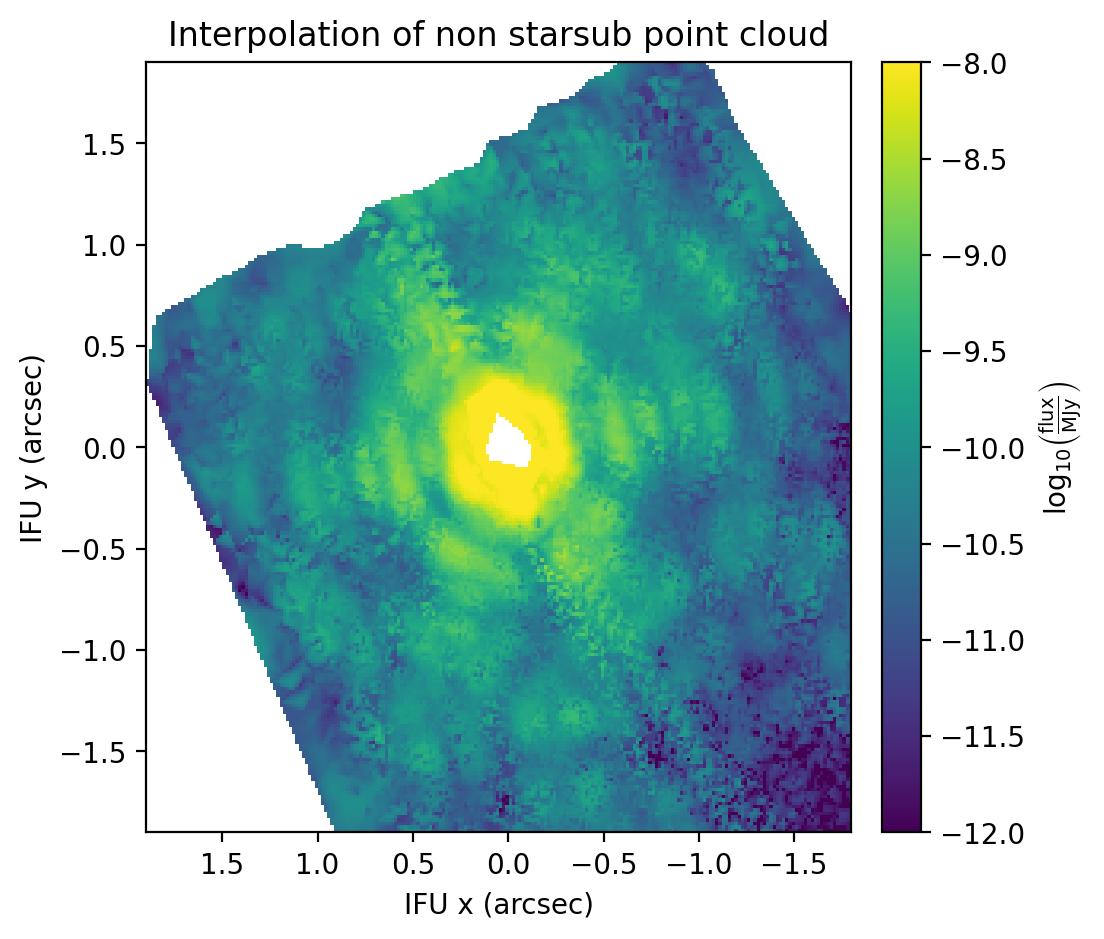

In [11]:
dramin, dramax, ddecmin, ddecmax = np.min(ra_vec),np.max(ra_vec),np.min(dec_vec),np.max(dec_vec) 
extent=[dramin, dramax, ddecmin, ddecmax]

N = 240
ra_vec = np.linspace(dramin,dramax,N)
dec_vec = np.linspace(ddecmin,ddecmax,N)
inp = np.meshgrid(ra_vec,dec_vec)
out = pointcloud_interp(inp[0],inp[1])

fig =plt.figure(figsize=(5,5),dpi=200)
im = plt.imshow(np.log10(abs(out)),origin='lower',extent=extent,vmin=-12,vmax=-8,aspect='auto')

plt.xlim([dramax-.1,dramin+.2])
plt.ylim([ddecmin+.1,ddecmax-.1])
cbar = fig.colorbar(im, fraction=0.05, pad=0.04)
cbar.set_label(r'log$_{10} \left(\frac{\mathrm{flux}}{\mathrm{MJy}}\right)$')
plt.xlabel('IFU x (arcsec)')
plt.ylabel('IFU y (arcsec)')
plt.title('Interpolation of non starsub point cloud')
plt.show()